* **Author:** Isaac Cobena Appiah
* **Date:** April-2026
* **Type:** Medium/Substack/Website Tutorial
## **The Algebra of Learning — Part 1: Inside the Neuron**

*A walkthrough of how neural networks are built, starting from the smallest possible piece. By the end, a neural network will feel less like scary maths magic and more like a stack of weighted sums with an on/off switch.*

In this article, I go back to the basics. To the single most important building block in modern AI. The one underneath everything — from Netflix recommendations to face unlock to the chatbot you argued with this morning.

That building block is the **neuron**. And here is the good news: it is not mysterious. It is a weighted sum with a squiggly switch on the end.

I *could* jump straight into deep networks with dozens of layers. But given how much these models run the world now — and how often you've probably seen words like "backpropagation," "gradient descent," and "activation function" flash past and felt your eyes glaze — I think it's worth taking two steps back. Before we can teach a network to learn anything (that's Part 2), we have to understand what a network *is* before any learning happens at all.

So this post is about the static architecture. The skeleton. The thing that exists before the first lesson.

Ready? Let's jump in.

### **What we will cover in this article**

1. How a neural network differs from plain old linear regression (it's closer than you think).
2. A made-up synthetic dataset, with simple numbers, so we can actually *see* the maths.
3. The single neuron — the atomic unit — broken down into two tiny operations.
4. How neurons stack into a layer, and why linear algebra quietly takes over.
5. Why nonlinearity is not optional (with a three-line proof you'll actually believe).
6. Putting it all together into a tiny untrained network.

A quick promise before we start: we will not hand-wave. Every claim gets derived, every line of code runs, every number is real. The whole point of this series is that you walk away understanding *why* neural networks work — not just which buttons to press.

### **The five-step algorithm hiding inside every neural network**

People talk about neural networks like they're alien technology. They're not. Strip away the jargon and **every** neural network, from our toy below to GPT-class giants, does exactly five things:

1. Make a prediction.
2. Measure how wrong it was.
3. Figure out which knobs caused the error or mistake.
4. Nudge those knobs slightly/a little.
5. Repeat.

That's the entire algorithm. The work — and honestly the fun — is making each of those five steps mathematically precise. Part 1 is about step 1: how a network makes a prediction in the first place. The other four steps are Parts 2 and 3.

### **A synthetic dataset with deliberately simple numbers**

Before we touch a neuron, let me introduce the simplest prediction problem I could cook up.

Imagine we've tracked a student over 100 days. Each day we wrote down four numbers:

- `sleep_hours` — how many hours they slept the night before
- `study_minutes` — how long (minutes) they studied that morning
- `prev_score` — yesterday's quiz score (a little "momentum" signal)
- `today_score` — the thing we want to predict

This is a **supervised regression** problem. Translated into plain English: we have inputs $\mathbf{x} \in \mathbb{R}^3$ (three numbers per day) and a continuous target $y \in \mathbb{R}$ (today's score), and we want a function $f(\mathbf{x}; \boldsymbol{\theta})$ that produces predictions as close to the truth as possible or that turns the inputs into the answer with as little error as possible. The "stuff the model adjusts while learning" gets the symbol $\boldsymbol{\theta}$ - shorthand for *all the learnable numbers in the model* — the knobs at once.

I'm keeping this tiny on purpose, for the same reason the best driving instructors start you in an empty car park: I want you to see every gear shift clearly before we hit the motorway.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Reproducibility — every figure and number in this post comes from this seed.
np.random.seed(42)

NB: Setting the **random seed** is not optional in a tutorial. Without it you can never tell whether a change in the output came from a change in your code or just from a different roll of the dice.

In [2]:
n_days = 100

sleep_hours   = np.random.normal(7, 1.5, n_days).clip(4, 10)
study_minutes = np.random.normal(30, 15, n_days).clip(0, 90)
prev_score    = np.random.normal(75, 10, n_days).clip(40, 100)

# Ground-truth generative rule. The network does NOT see this — it must discover it.
true_w = np.array([2.5, 0.8, 0.3])
noise  = np.random.normal(0, 5, n_days)

today_score = (
    true_w[0] * sleep_hours
    + true_w[1] * (study_minutes / 10)
    + true_w[2] * (prev_score / 10)
    + 50
    + noise
).clip(40, 100)

study_data = pd.DataFrame({
    'sleep_hours':   sleep_hours,
    'study_minutes': study_minutes,
    'prev_score':    prev_score,
    'today_score':   today_score,
})

print(study_data.head().round(2))
print(f"\nMean score: {study_data['today_score'].mean():.2f}")
print(f"Range:      {study_data['today_score'].min():.1f} – {study_data['today_score'].max():.1f}")

   sleep_hours  study_minutes  prev_score  today_score
0         7.75           8.77       78.58        68.28
1         6.79          23.69       80.61        68.49
2         7.97          24.86       85.83        78.23
3         9.28          17.97       85.54        80.27
4         6.65          27.58       61.22        70.56

Mean score: 72.36
Range:      61.6 – 86.9


**A quick note on what we just did.** We *generated* the data from a rule we know (`true_w`) plus a dollop of random noise. The network never sees `true_w` or gets to peek at that rule. Its job is to rediscover that rule from the observations alone.

Why bother with fake data? Because it's the cleanest sanity test there is or for any learning algorithm. if a model can't recover a rule we *know* is sitting in the data, it stands no chance on real-world data where nobody knows the rule. Toy datasets aren't a cop-out — they're a controlled experiment.

Now we have data. The next question is the smallest possible thing that can look at this data and produce a prediction.

### **The Atomic Unit — A Single Neuron**

If a network is going to learn, where does the learning actually *live*? Where is the knowledge stored?

The honest answer is that it lives inside very small tiny mathematical units called **neurons**. On their own, one at a time, neurons do almost nothing impressive. Stacked, they do everything modern AI does. So let's build one slowly and carefully.

Picture answering a single question on a quiz. How well you do depends on three things: how rested you are (How well he slept), how much you prepared or studied, and your baseline ability before either of those kicks in ( what you bring to the page before sleep or study enter the picture). A neuron models exactly this, in two operations, in this exact order.

#### **Step one: The Weighted Sum (the "Pre-Activation")**

Given inputs $x_1, x_2, \ldots, x_d$, a neuron computes:

$$z = w_1 x_1 + w_2 x_2 + \cdots + w_d x_d + b = \mathbf{w}^\top \mathbf{x} + b$$

Don't let the symbols scare you. Here's the entire cast of characters:

- $\mathbf{x} \in \mathbb{R}^d$ : the input vector 
- $\mathbf{w} \in \mathbb{R}^d$ : the learned weights — how much each input matters 
- $b \in \mathbb{R}$ : the bias — the neuron's built-in offset, independent of any input 
- $z \in \mathbb{R}$ : the pre-activation — the raw weighted sum 

A nice way to picture this: $z = \mathbf{w}^\top \mathbf{x} + b$ describes a tilted plane (a *hyperplane*) sitting in the input space. The weights $\mathbf{w}$ control its *tilt* — how steeply $z$ rises as you move along each input. The bias $b$ controls its *position* — how far the plane floats from the origin. Without a bias, the plane is pinned to pass through zero, which is a surprisingly nasty restriction we'll want to avoid.

And here's a reassuring secret: **a neuron with no activation function is just linear regression.** That's not an insult. It's the foundation everything else is built on.

#### **Step two: The Activation (the Squiggly Switch)**

The second operation passes $z$ through an **activation function** $g$:

$$a = g(z)$$

For now we'll use the most popular activation in modern networks, the **Rectified Linear Unit**:

$$\text{ReLU}(z) = \max(0, z)$$

In plain English: "if the weighted sum is positive, keep it; if it's negative, flatten it to zero." That's it. Why we need an activation at all — and why this particular one — is the subject of Section 5. For now, just trust that this little switch is where the magic comes from.

#### **Coding a single neuron**

In [3]:
class SingleNeuron:
    """
    One neuron computing  a = ReLU(w·x + b).
    """

    def __init__(self, n_inputs=2, seed=0):
        rng = np.random.default_rng(seed)
        # Small random weights. The "small" matters — see Part 2 on initialization.
        self.w = rng.normal(0, 0.1, size=n_inputs)
        # Bias initialized to zero. The "zero" matters — see Part 2.
        self.b = 0.0

    def forward(self, x):
        z = self.w @ x + self.b      # pre-activation
        a = max(0.0, z)              # ReLU activation
        return z, a                  # return both so we can inspect the raw output


neuron = SingleNeuron(n_inputs=2, seed=0)
print(f"Initial weights: {neuron.w.round(3)}")
print(f"Initial bias:    {neuron.b}")

scenarios = [
    ("Great sleep, studied hard",   9, 60),
    ("Poor sleep, studied hard",    4, 60),
    ("Great sleep, no study",       9,  5),
    ("Terrible sleep, no study",    3,  5),
]

print("\nTesting an untrained neuron on four scenarios:\n")
for desc, sleep, study in scenarios:
    x = np.array([sleep, study], dtype=float)
    z, a = neuron.forward(x)
    print(f"  {desc:30s}  z = {z:+6.3f}   a = ReLU(z) = {a:.3f}")

Initial weights: [ 0.013 -0.013]
Initial bias:    0.0

Testing an untrained neuron on four scenarios:

  Great sleep, studied hard       z = -0.679   a = ReLU(z) = 0.000
  Poor sleep, studied hard        z = -0.742   a = ReLU(z) = 0.000
  Great sleep, no study           z = +0.047   a = ReLU(z) = 0.047
  Terrible sleep, no study        z = -0.028   a = ReLU(z) = 0.000


Now look closely at the output, because this is the part most tutorials gloss over. The pre-activations $z$ are *varied* (around −0.74, −0.68, +0.05, −0.03) — the neuron really is responding differently to different inputs. It just so happens that ReLU clips three of those four to zero because they came out negative.

I can sense the question forming:

> *"So the neuron isn't blind — it's seeing the inputs. It's just guessing wrong about which combinations matter?"*

Exactly right. A freshly initialized neuron has *random opinions* about which inputs matter, and with weights this small, those opinions barely register. The neuron is perfectly *capable* of telling inputs apart. It just has nothing intelligent to say about them yet. Turning that raw capability into knowledge is exactly what learning does — and that's Part 2.

#### **Why Random Weights, not zero weights?**

Here's a question that trips up a lot of beginners:

> *"Why start with random numbers? Why not start everything at zero and let the network figure it out?"*

Because zeros are a trap. If every weight in a layer starts at zero, then every neuron computes exactly the same thing. They produce identical outputs. When learning kicks in (Part 2), they receive identical updates. They stay identical *forever*. You've paid for $n$ neurons and you're getting the work of one.

This is the **symmetry problem**, and random initialization is what breaks it. Each neuron starts with a different random tilt, so each begins with a different *direction* of opinion. Learning then sharpens those directions into something useful. The diversity has to come from somewhere, and random init is where.

Biases, on the other hand, are usually started at zero — random weights already break the symmetry, so randomizing the bias would just add noise for no benefit. More on this in Part 2, where initialization starts to really matter.

### **From Neuron to Layer — linear algebra takes over**

One neuron can only learn one linear combination of the inputs. Real patterns are multi-dimensional, and we have a whole quiz to predict, not one question. So we scale up.

> *"If one neuron is answering one question, then a layer must be answering the whole quiz at once?"*

That's the right mental picture — and the moment we go from one neuron to many, **linear algebra quietly takes over the room.** Stop thinking about single numbers; start thinking about matrices.

#### **Stacking Neurons into a Matrix**

Take $n$ neurons side by side, each receiving the same $d$-dimensional input. Neuron $i$ has its own weight vector $\mathbf{w}_i \in \mathbb{R}^d$ and bias $b_i$. Stack those weight vectors as the rows of one big matrix:

$$\mathbf{W} = \begin{bmatrix} \mathbf{w}_1^\top \\ \mathbf{w}_2^\top \\ \vdots \\ \mathbf{w}_n^\top \end{bmatrix} \in \mathbb{R}^{n \times d}, \qquad \mathbf{b} \in \mathbb{R}^n$$

And now — this is the elegant part — the entire layer's pre-activation is *one* matrix–vector product:

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{b}, \qquad \mathbf{z} \in \mathbb{R}^n$$

followed by the activation applied element by element:

$$\mathbf{a} = g(\mathbf{z})$$

| Symbol | Shape | Meaning |
|---|---|---|
| $\mathbf{x}$ | $(d,)$ | one input example |
| $\mathbf{W}$ | $(n, d)$ | row $i$ = neuron $i$'s weights; column $j$ = how feature $j$ feeds every neuron |
| $\mathbf{b}$ | $(n,)$ | one bias per neuron |
| $\mathbf{z}, \mathbf{a}$ | $(n,)$ | the layer's pre-activation and activation |

The geometric picture is worth holding onto: each row of $\mathbf{W}$ defines a hyperplane, and the layer projects the input onto all $n$ of them at once, producing an $n$-dimensional summary. The next layer then works on *that* summary, not the raw input. That's how networks build features on top of features — each layer reshapes the space the next one gets to see.

#### **Why we standardize features first (don't skip this)**

There's one detail we have to handle before any layer produces results worth showing — and it's the single most common reason "tutorial code that should work" mysteriously doesn't.

Look at the raw scales in our data:

- `sleep_hours` lives in $[4, 10]$
- `study_minutes` lives in $[0, 90]$
- `prev_score` lives in $[40, 100]$

Three wildly different scales. A weight of 1.0 on `study_minutes` has *fifteen times* the influence of the same weight on `sleep_hours`, purely because of the units. That's not a choice we want the accident of measurement to make for us — we want the network to decide which features matter.

The fix is **standardization**: shift each feature to zero mean and scale it to unit standard deviation.

$$\tilde{x}_j = \frac{x_j - \mu_j}{\sigma_j}$$

After this, every feature lives in roughly the same numerical range, and the optimizer (Part 3) can push every weight with comparable steps.

In [4]:
X_raw = study_data[['sleep_hours', 'study_minutes', 'prev_score']].values
y_raw = study_data['today_score'].values

X_mean, X_std = X_raw.mean(axis=0), X_raw.std(axis=0)
y_mean, y_std = y_raw.mean(),       y_raw.std()

X = (X_raw - X_mean) / X_std
y = (y_raw - y_mean) / y_std  # standardize the target too, so loss magnitudes stay sane

print(f"X mean ≈ {X.mean(axis=0).round(3)},  X std ≈ {X.std(axis=0).round(3)}")
print(f"y mean ≈ {y.mean():.3f},  y std ≈ {y.std():.3f}")

X mean ≈ [ 0.  0. -0.],  X std ≈ [1. 1. 1.]
y mean ≈ -0.000,  y std ≈ 1.000


If you remember one practical thing from this whole post, make it this one. A huge fraction of "my network won't train" stories trace straight back to a skipped standardization step.

#### **Coding a Layer**

While we're here, we'll also upgrade the weight initialization. For ReLU networks the standard choice is **He initialization** — drawing weights from a normal distribution with variance $2/n_\text{in}$. This keeps the signal from blowing up or fading away as it passes through layers. We'll derive *why* this exact factor in Part 2; for now, take it as a well-earned recipe.

In [5]:
class Layer:
    """
    A fully-connected layer: a = ReLU(W x + b).
    Operates on a whole batch of examples at once.
    """

    def __init__(self, n_inputs, n_neurons, seed=0):
        rng = np.random.default_rng(seed)
        # He initialization: Var(w) = 2 / n_inputs
        self.W = rng.normal(0, np.sqrt(2.0 / n_inputs), size=(n_neurons, n_inputs))
        self.b = np.zeros(n_neurons)

    def forward(self, X):
        # X has shape (batch_size, n_inputs)
        z = X @ self.W.T + self.b     # broadcasting adds bias to every row
        a = np.maximum(0, z)          # ReLU, applied elementwise
        return a


layer = Layer(n_inputs=3, n_neurons=4, seed=1)
print(f"Weight matrix shape: {layer.W.shape}   (4 neurons × 3 inputs)")
print(f"Bias shape:          {layer.b.shape}")

out = layer.forward(X[:3])
print(f"\nOutput shape for 3 examples: {out.shape}   (3 examples × 4 neuron outputs)")
print("Layer output for first 3 days (each row = one day, each column = one neuron):")
print(out.round(3))

# How healthy is the layer? With He init + ReLU, about half the activations should be > 0.
all_out = layer.forward(X)
fraction_active = (all_out > 0).mean()
print(f"\nFraction of activations > 0: {fraction_active:.2%}")
print("(About 50% is healthy for ReLU + He init — neither dead nor saturated.)")

Weight matrix shape: (4, 3)   (4 neurons × 3 inputs)
Bias shape:          (4,)

Output shape for 3 examples: (3, 4)   (3 examples × 4 neuron outputs)
Layer output for first 3 days (each row = one day, each column = one neuron):
[[0.    0.    0.    0.257]
 [0.    0.    0.    0.197]
 [0.247 0.    0.    0.636]]

Fraction of activations > 0: 49.00%
(About 50% is healthy for ReLU + He init — neither dead nor saturated.)


That ~49% figure is not a coincidence. With weights drawn symmetrically around zero and a zero bias, half the pre-activations land negative and get clipped by ReLU. This is the textbook fingerprint of a *healthy* untrained ReLU layer — exactly what you want before training starts. If you ever see 0% or 100%, something is wrong with your initialization.

> *"So even before learning, the network is at least... awake. Half its neurons fire on any given input. It's not asleep, and it's not screaming."*

That's a lovely way to put it. With the wrong initialization you can ship a network that's already broken — neurons that will never fire, or every neuron blaring on every input. He init makes sure the network shows up to the exam alert and ready, even before it knows a single thing.

### **Why Nonlinearity is Not Optional**

We've built one neuron and one layer. Here's the obvious next thought: why not just stack a pile of linear layers and call that a deep network?

The answer is **maths**, and it comes in the form of the single most important theoretical fact in this entire series:

> **Claim.** Stacking linear layers with no nonlinear activation between them produces a function mathematically identical to a *single* linear layer. No matter how deep you go.

This isn't a vibe. It's a three-line proof.

#### **The proof**

Let layer 1 compute:

$$\mathbf{z}_1 = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1$$

Let layer 2 take that as input, with *no* activation between them:

$$\mathbf{z}_2 = \mathbf{W}_2 \mathbf{z}_1 + \mathbf{b}_2$$

Substitute the first into the second:

$$\mathbf{z}_2 = \mathbf{W}_2(\mathbf{W}_1 \mathbf{x} + \mathbf{b}_1) + \mathbf{b}_2 = (\mathbf{W}_2 \mathbf{W}_1)\mathbf{x} + (\mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2)$$

Define $\mathbf{W}' = \mathbf{W}_2 \mathbf{W}_1$ and $\mathbf{b}' = \mathbf{W}_2 \mathbf{b}_1 + \mathbf{b}_2$. Then:

$$\mathbf{z}_2 = \mathbf{W}' \mathbf{x} + \mathbf{b}'$$

A single linear layer. The depth bought us nothing. ∎

The consequence is brutal and beautiful: without nonlinearity, a 100-layer network has exactly the same expressive power as plain old regression. **The only thing that makes depth worth anything is the nonlinear activation sitting between the layers.**

#### **ReLU and its derivative**

ReLU is the modern default:

$$\text{ReLU}(z) = \max(0, z)$$

and its derivative — which we'll need badly in Part 2 — is:

$$\frac{d}{dz}\text{ReLU}(z) = \begin{cases} 1 & z > 0 \\ 0 & z < 0 \\ \text{undefined} & z = 0 \quad(\text{in practice: set to 0}) \end{cases}$$

ReLU is *piecewise linear* — a flat bit then a sloped bit. But here's the trick: composing many piecewise-linear functions is **not** linear. It's piecewise linear with an exploding number of pieces. That's exactly where the power of depth comes from.

Think of each ReLU neuron as contributing one "fold" to a piecewise approximation of the target function. More neurons, more folds, finer approximation. This is the intuition behind the famous Universal Approximation Theorem: a wide enough network of ReLU neurons can approximate any continuous function to whatever precision you like.

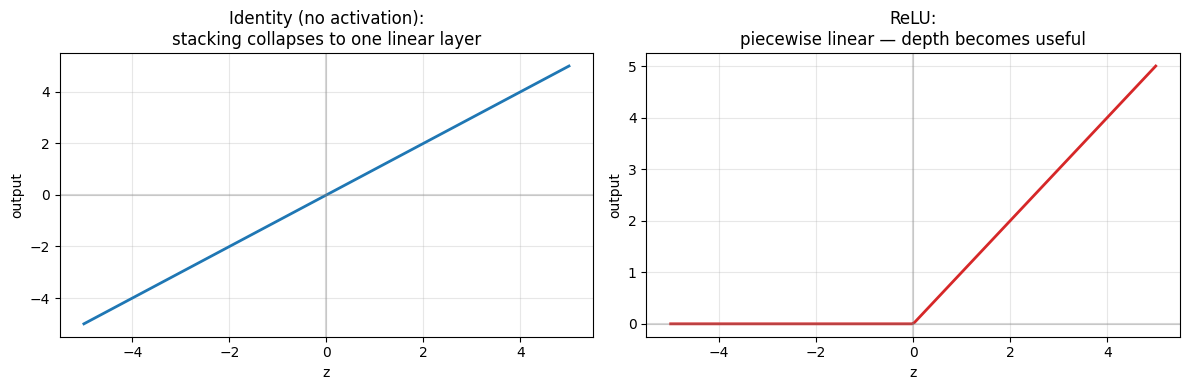

In [6]:
z = np.linspace(-5, 5, 200)
identity = z
relu     = np.maximum(0, z)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(z, identity, linewidth=2)
axes[0].axhline(0, color='gray', alpha=0.3); axes[0].axvline(0, color='gray', alpha=0.3)
axes[0].set_title('Identity (no activation):\nstacking collapses to one linear layer')
axes[0].set_xlabel('z'); axes[0].set_ylabel('output'); axes[0].grid(alpha=0.3)

axes[1].plot(z, relu, color='C3', linewidth=2)
axes[1].axhline(0, color='gray', alpha=0.3); axes[1].axvline(0, color='gray', alpha=0.3)
axes[1].set_title('ReLU:\npiecewise linear — depth becomes useful')
axes[1].set_xlabel('z'); axes[1].set_ylabel('output'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

#### **The dead-ReLU problem (a sneak preview)**

ReLU has one famous failure mode, and I'd rather you hear about it now than be ambushed later. Look at its derivative again: it's *zero* for any $z < 0$. So if a neuron's weighted sum comes out negative on *every* training input, ReLU outputs zero for all of them — *and* the gradient blocks any update to that neuron. The neuron is dead, and it can't climb back out.

This is why bias initialization sometimes uses a small positive nudge (say 0.01) for ReLU networks — to keep $z$ above zero at the start and stop neurons from being dead on arrival. We'll watch *why* the gradient dies fall straight out of the chain rule in Part 2, along with fixes like Leaky ReLU.

For now, the takeaway is simple: **ReLU's simplicity has a cost, and that cost has a name. Knowing the name is half the battle when you debug it.**

### **Putting it all together — the network at birth**

We have every piece. Let's assemble them into the architecture that Part 2 will teach to learn.

In [7]:
class TinyNet:
    """
    Two-layer network:
       input (3) → Linear(3, h) → ReLU → Linear(h, 1) → ŷ
    No learning yet — this just shows the forward pass.
    """

    def __init__(self, n_inputs=3, n_hidden=8, seed=0):
        rng = np.random.default_rng(seed)
        # He init for hidden layer
        self.W1 = rng.normal(0, np.sqrt(2.0 / n_inputs),  size=(n_hidden, n_inputs))
        self.b1 = np.zeros(n_hidden)
        # He init for output layer (input dim now = n_hidden)
        self.W2 = rng.normal(0, np.sqrt(2.0 / n_hidden),  size=(1, n_hidden))
        self.b2 = np.zeros(1)

    def forward(self, X):
        z1 = X @ self.W1.T + self.b1     # (batch, n_hidden)
        a1 = np.maximum(0, z1)            # ReLU
        z2 = a1 @ self.W2.T + self.b2     # (batch, 1)
        y_hat = z2.flatten()              # (batch,)
        return y_hat

    def n_parameters(self):
        return self.W1.size + self.b1.size + self.W2.size + self.b2.size


net = TinyNet(n_inputs=3, n_hidden=8, seed=0)
print(f"Architecture: 3 → 8 → 1")
print(f"Total parameters: {net.n_parameters()}")
print(f"  W1: {net.W1.shape},  b1: {net.b1.shape}")
print(f"  W2: {net.W2.shape},  b2: {net.b2.shape}")

# Forward pass on the standardized data
y_hat = net.forward(X)
print(f"\nPredictions on 100 days, before any learning:")
print(f"  mean = {y_hat.mean():.3f}    (target mean = 0 since y is standardized)")
print(f"  std  = {y_hat.std():.3f}     (target std  = 1)")

# MSE on standardized targets
mse = np.mean((y_hat - y) ** 2)
print(f"\n  MSE on standardized targets: {mse:.3f}")
print(f"  (A model that always predicts 0 would get MSE ≈ 1, since Var(y) = 1.)")
print(f"  (We're at {mse:.2f} — basically random. Learning hasn't started yet.)")

Architecture: 3 → 8 → 1
Total parameters: 41
  W1: (8, 3),  b1: (8,)
  W2: (1, 8),  b2: (1,)

Predictions on 100 days, before any learning:
  mean = -0.678    (target mean = 0 since y is standardized)
  std  = 0.688     (target std  = 1)

  MSE on standardized targets: 1.849
  (A model that always predicts 0 would get MSE ≈ 1, since Var(y) = 1.)
  (We're at 1.85 — basically random. Learning hasn't started yet.)


Forty-one numbers. That's the whole brain right now — each one randomly assigned, and together encoding... nothing useful yet. Look at the MSE: about 1.85. A model that lazily predicts the average every single time would score around 1.0. So our freshly built network is actively *worse* than the laziest possible baseline.

> *"So when does it actually start learning?"*

That's Part 2. We've built the architecture. Next, we teach it.

### **What we've built — a recap**

In Part 1 we covered the static side of neural networks. Here's everything you now own, with all the pieces named:

- **Neuron** : $a = g(\mathbf{w}^\top \mathbf{x} + b)$ — weighted sum, then a nonlinearity. 
- **Pre-activation** $z$ : $z = \mathbf{w}^\top \mathbf{x} + b$. A hyperplane in input space. 
- **Bias** $b$ : The neuron's built-in offset. Frees the hyperplane from the origin. 
- **Layer** : $\mathbf{a} = g(\mathbf{W}\mathbf{x} + \mathbf{b})$ — many neurons computed in parallel by one matrix multiply. 
- **Weight matrix** $\mathbf{W}$ : Rows = individual neurons. Columns = how each feature feeds every neuron. 
- **Why standardize** : Different input scales distort the loss surface and break training. Standardize first, always. 
- **Why nonlinearity** : Stacked linear layers collapse to one linear layer. The activation is what makes depth useful. 
- **ReLU** : $\max(0, z)$. Simple, fast, the modern default — but it can die (gradient is 0 for negative $z$). 
- **He initialization** : Variance $2/n_\text{in}$. Keeps signal magnitudes stable through depth in ReLU networks. 
- **Symmetry problem** : Why we use random, not zero, weights: identical neurons stay identical forever. 

### **What's coming next**

**Part 2: Backpropagation.** We've built a network that produces random noise. Next, we teach it to produce *good* answers — by deriving, from scratch and with zero hand-waving, exactly how the chain rule lets a network work out which of its 41 numbers to adjust, and by how much, to make tomorrow's prediction better than today's. We'll work a full forward and backward pass by hand, watch the dead-ReLU problem fall straight out of the maths, and see the MSE drop from 1.85 to something genuinely useful.

**Part 3: Optimizers and frameworks.** We'll move past plain gradient descent to Adam (the modern default), explain *why* it works, and rebuild the whole thing in TensorFlow and PyTorch — both of which automate everything we wrote by hand, and neither of which adds any magic the maths doesn't already justify.

If anything in this part felt hand-wavy, that's a signal to re-derive it. Every claim has maths behind it. The maths is the point.

See you in Part 2.